# Smart Tourism Project 

## Domain : **Tourism**

### About the Domain

Smart Tourism uses  Machine Learning (ML),
and Data Analytics to make travelling easier, safer, and more enjoyable.
It helps tourists choose the best places to visit, estimate travel
budgets, check weather conditions, avoid crowded places, and identify
the best travel routes. It also helps tourism organizations improve
services and make data-driven decisions.

------------------------------------------------------------------------

# Crowd Prediction

## Business Problem Statement

Tourism departments and hotels need to estimate the expected number of
visitors at tourist destinations in advance. Accurate crowd prediction
helps manage resources, improve visitor experience, reduce congestion,
and support better planning during weekends, holidays, and festivals.

## Objective

Develop a Machine Learning model to predict the expected number of
tourists visiting a destination using historical visitor data and
seasonal factors.

## Dataset Source

-   **Dataset:** `spot_visitors.csv`
-   **Source:** semi-synthetic dataset
-   **Target Column (Y):** `total_visitors`

# 0.Data: Collection & Loading 
#### Modules
All libraries used in this notebook.

In [1]:
!pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display and plotting settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

# Path to your database file
db_path = r'C:\Users\AKSHAT\OneDrive\Desktop\Tourism Data\smart_tourism.db'

# Connect to SQLite database
connection = sqlite3.connect(db_path)

# Load the table into a DataFrame
df_raw = pd.read_sql_query(
    "SELECT * FROM spot_visitors",
    connection
)

display(df_raw.head())

print("Database loaded successfully!")

# Close the connection after reading
connection.close()

,Spot_Name,District,Category,Year,Month,Season,Festival,Total_Visitors
0,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,January,Winter,"Bhogi, Sankranti/Pongal, New Year's Day, Repub...",775
1,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,February,Winter,No Major Festival / Public Holiday,592
2,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,March,Summer,"Maha Shivaratri, Holi",439
3,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,April,Summer,"Ugadi, Sri Rama Navami, Eid-ul-Fitr, Ambedkar ...",432
4,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,May,Summer,May Day,496


Database loaded successfully!


## 2. Basic Raw Data Checks
Load the table directly from the database and take a first look at it before doing anything else.

In [4]:
df_raw.tail()


,Spot_Name,District,Category,Year,Month,Season,Festival,Total_Visitors
6643,palle prakruthi vanam,Mahabubabad,Park/Garden,2025,August,Monsoon,"Krishna Ashtami, Vinayaka Chavithi, Independen...",2945
6644,palle prakruthi vanam,Mahabubabad,Park/Garden,2025,September,Monsoon,Bathukamma (Engili Pula to Saddula),3087
6645,palle prakruthi vanam,Mahabubabad,Park/Garden,2025,October,Post-Monsoon,"Vijaya Dasami/Dussehra, Diwali/Deepavali",4741
6646,palle prakruthi vanam,Mahabubabad,Park/Garden,2025,November,Post-Monsoon,No Major Festival / Public Holiday,4692
6647,palle prakruthi vanam,Mahabubabad,Park/Garden,2025,December,Winter,Christmas,6776


## Dataset Overview

This dataset comes from the `spot_visitors` table inside `smart_tourism.db`, a SQLite database. It tracks **monthly visitor footfall for tourist spots across Telangana**, giving one row per place, per month, per year.

- **Rows:** 6,504
- **Columns:** 8
- **Time span:** 2024 – 2026 (2 years, all 12 months covered)
- **Unique places tracked:** 271
- **districts covered:** 33
- **Granularity:** One record = one tourist spot's visitor count for a single month of a single year

### Column Dictionary

| Column | Data Type | Description |
|---|---|---|
| `spot_name` | Text | Name of the tourist spot (e.g., "Air Force Academy Museum"). 271 unique places. |
| `district` | Text | The district in Telangana where the spot is located (e.g., "Medchal-Malkajgiri"). 33 unique districts. |
| `category` | Text | Type/classification of the spot (e.g., "Museum/Gallery", "Temple", "Waterfall", "Fort"). 14 unique categories. |
| `year` | Integer | The year of the record — 2024, 2025, or 2026. |
| `month` | Text | The calendar month of the record (January–December). |
| `season` | Text | The season the month falls into — Winter, Summer, Monsoon, or Post-Monsoon. |
| `festival` | Text | Named festival(s) or public holiday(s) occurring in that month, or "No Major festival / Public Holiday" if none. |
| `total_visitors` | Integer | Number of visitors recorded for that place, in that month and year — the main metric of interest. |

### Purpose

This dataset supports analysis of **tourism footfall patterns** — such as which places, categories, districts, and seasons attract the most visitors, and whether festivals or time of year influence visitor numbers.

**Column data types and non-null counts**

In [5]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6648 entries, 0 to 6647
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Spot_Name       6648 non-null   object
 1   District        6648 non-null   object
 2   Category        6648 non-null   object
 3   Year            6648 non-null   int64 
 4   Month           6648 non-null   object
 5   Season          6648 non-null   object
 6   Festival        6648 non-null   object
 7   Total_Visitors  6648 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 415.6+ KB


**Numeric summary**

In [6]:
df_raw.describe()


,Year,Total_Visitors
count,6648.000000,6648.000000
mean,2024.500000,9464.535349
std,0.500038,26121.954770
min,2024.000000,129.000000
25%,2024.000000,515.750000
50%,2024.500000,3113.000000
75%,2025.000000,7083.500000
max,2025.000000,574904.000000


**Categorical summary (counts, unique values, top value)**

In [7]:
df_raw.describe(include='object')


,Spot_Name,District,Category,Month,Season,Festival
count,6648,6648,6648,6648,6648,6648
unique,271,33,14,12,4,18
top,Pocharam Dam & Wildlife Sanctuary,Hyderabad,Temple,January,Monsoon,"Bhogi, Sankranti/Pongal, New Year's Day, Repub..."
freq,48,1608,1416,554,2216,554


**Number of unique values per column**

This tells us which columns are IDs/high-cardinality text vs. true categories.

In [8]:
df_raw.nunique().sort_values()


Year                 2
Season               4
Month               12
Category            14
Festival            18
District            33
Spot_Name          271
Total_Visitors    3930
dtype: int64

# 1. Data Validation & Normalization:
Before analysing the data, we check that it is trustworthy: missing values, duplicate rows, valid ranges, and consistent category labels.

**1.1 Convert Column Names to Lowercase**

Standardizing column names by converting all column headers to lowercase for uniform data access across the analysis.

In [9]:
# Convert column names to lowercase
df_raw.columns = df_raw.columns.str.lower()
print("Column names converted to lowercase:")
print(list(df_raw.columns))


Column names converted to lowercase:
['spot_name', 'district', 'category', 'year', 'month', 'season', 'festival', 'total_visitors']


**1.2 Missing values**

In [10]:
missing = df_raw.isnull().sum()

pd.DataFrame({'missing_count': missing})


,missing_count
spot_name,0
district,0
category,0
year,0
month,0
season,0
festival,0
total_visitors,0


**3.2 Duplicate rows**

In [11]:
dup_count = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")
if dup_count > 0:
    display(df_raw[df_raw.duplicated(keep=False)].sort_values(list(df_raw.columns)).head(10))


Fully duplicated rows: 0


**1.3 Valid ranges for numeric fields**

`total_visitors` should be positive, and `year` should fall within a sensible range.

In [12]:
print("total_visitors min/max:", df_raw['total_visitors'].min(), '/', df_raw['total_visitors'].max())
print("Any zero or negative visitors?:", (df_raw['total_visitors'] <= 0).sum())
print("year values present:", sorted(df_raw['year'].unique()))


total_visitors min/max: 129 / 574904
Any zero or negative visitors?: 0
year values present: [np.int64(2024), np.int64(2025)]


**1.4 Consistency of categorical labels**

Checking for stray whitespace/casing issues, and that `month` and `season` only contain expected values.

In [13]:
expected_months = ['January','February','March','April','May','June','July',
                   'August','September','October','November','December']
expected_seasons = ['Winter','Summer','Monsoon','Post-Monsoon']

print("Unexpected month values:", set(df_raw['month'].unique()) - set(expected_months))
print("Unexpected season values:", set(df_raw['season'].unique()) - set(expected_seasons))

# whitespace / hidden-character check on text columns
text_cols = df_raw.select_dtypes(include='object').columns
for c in text_cols:
    stripped_diff = (df_raw[c].astype(str).str.strip() != df_raw[c].astype(str)).sum()
    if stripped_diff > 0:
        print(f"'{c}' has {stripped_diff} values with leading/trailing whitespace")
print("Whitespace check complete.")


Unexpected month values: set()
Unexpected season values: set()
Whitespace check complete.



**1.5 Clean the data**

Based on the checks above we drop the one exact duplicate row (if any) found in step 3.2. No missing values or invalid ranges were found, so no imputation is needed.

In [14]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Rows before cleaning: {df_raw.shape[0]} | Rows after cleaning: {df.shape[0]}")

Rows before cleaning: 6648 | Rows after cleaning: 6648


# 2.EDA Analysis (Uni, Bi, Mul ) 

### 2.1 Univariate Analysis
Looking at each variable on its own — its distribution, spread, and most common values.

#### total_visitors (numeric)

In [15]:
print(df['total_visitors'].describe())
print("Skewness:", round(df['total_visitors'].skew(), 2))
print("Median:", df['total_visitors'].median())


count      6648.000000
mean       9464.535349
std       26121.954770
min         129.000000
25%         515.750000
50%        3113.000000
75%        7083.500000
max      574904.000000
Name: total_visitors, dtype: float64
Skewness: 8.16
Median: 3113.0


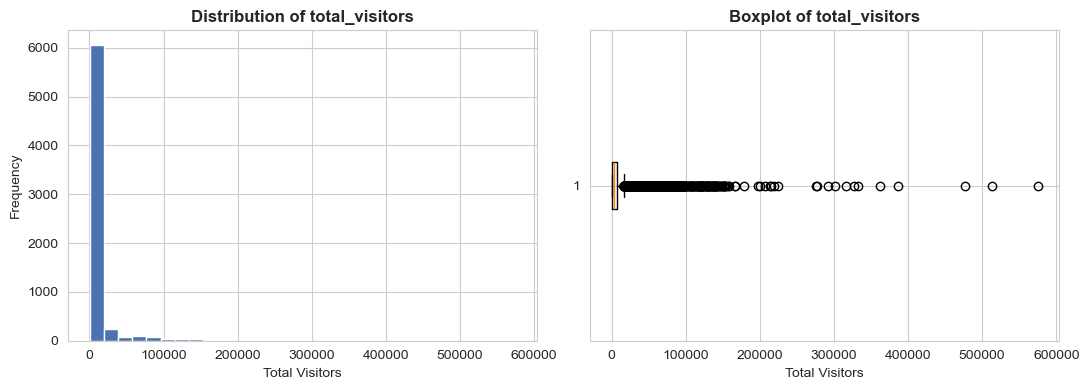

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['total_visitors'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of total_visitors')
axes[0].set_xlabel('Total Visitors')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['total_visitors'], vert=False)
axes[1].set_title('Boxplot of total_visitors')
axes[1].set_xlabel('Total Visitors')

plt.tight_layout()
plt.show()


**Insight:** `total_visitors` is strongly right-skewed — most spot-months attract a modest crowd (median ≈ 3,100), while a small number of visits/locations pull in very large numbers (max ≈ 620K), stretching the tail. This is typical for tourism data, where a handful of iconic spots dominate footfall. We'll keep the raw values for now and note that any modelling later would benefit from a log transform or from treating the top values as high-traffic outliers rather than errors.

#### year

In [17]:
year_counts = df['year'].value_counts().sort_index()
print(year_counts)


year
2024    3324
2025    3324
Name: count, dtype: int64


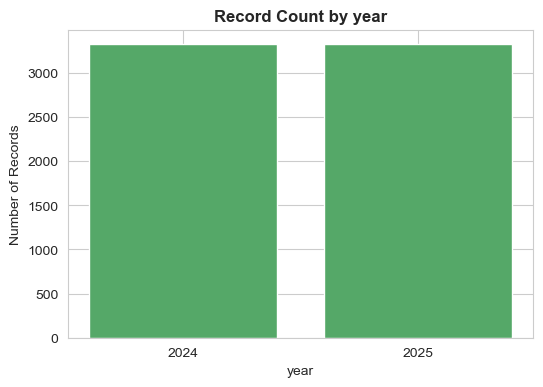

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(year_counts.index.astype(str), year_counts.values, color='#55A868')
plt.title('Record Count by year')
plt.xlabel('year')
plt.ylabel('Number of Records')
plt.show()


**Insight:** Records are spread across 2024, 2025 and 2026 in roughly similar numbers, so the dataset isn't skewed toward one particular year — comparisons across years should be reasonably fair.

#### season

In [19]:
season_counts = df['season'].value_counts()
print(season_counts)


season
Monsoon         2216
Winter          1662
Summer          1662
Post-Monsoon    1108
Name: count, dtype: int64


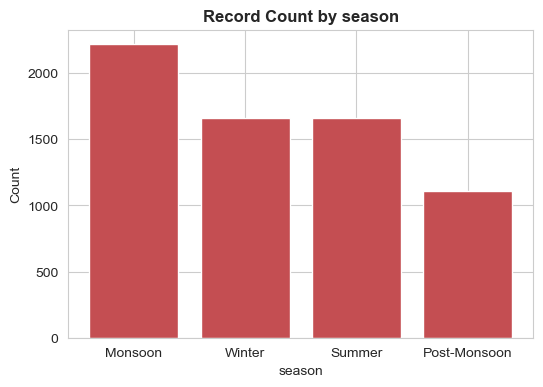

In [20]:
plt.figure(figsize=(6, 4))
plt.bar(season_counts.index, season_counts.values, color='#C44E52')
plt.title('Record Count by season')
plt.xlabel('season')
plt.ylabel('Count')
plt.show()


**Insight:** Records are fairly evenly distributed across the four seasons, which makes sense since each month naturally maps to one season and every place/year combination contributes one row per month.

#### month

In [21]:
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
month_counts = df['month'].value_counts().reindex(month_order)
print(month_counts)


month
January      554
February     554
March        554
April        554
May          554
June         554
July         554
August       554
September    554
October      554
November     554
December     554
Name: count, dtype: int64


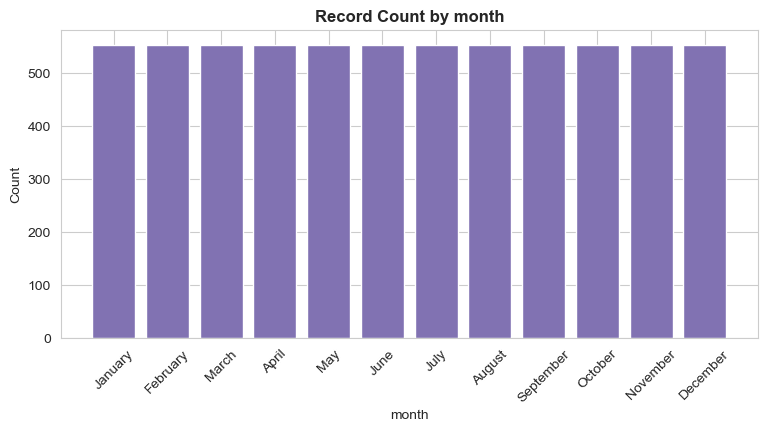

In [22]:
plt.figure(figsize=(9, 4))
plt.bar(month_counts.index, month_counts.values, color='#8172B2')
plt.title('Record Count by month')
plt.xlabel('month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


**Insight:** Every month is represented an equal number of times, confirming the dataset is one row per place, per month, per year — a clean, balanced panel rather than a random sample.

#### category

In [23]:
cat_counts = df['category'].value_counts()
print(cat_counts)


category
Temple                    1416
Lake/Reservoir             888
Other/Cultural Site        888
Cave/Hill/Viewpoint        552
Fort                       552
Dam/Barrage                480
Park/Garden                432
Museum/Gallery             336
Wildlife/National Park     336
Monument/Tomb              312
Palace/Heritage            168
Waterfall                  120
Church/Cathedral            96
Religious Site - Other      72
Name: count, dtype: int64


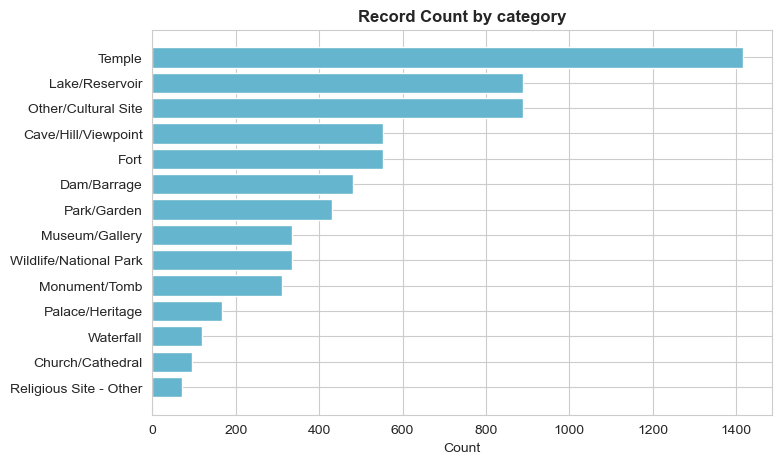

In [24]:
plt.figure(figsize=(8, 5))
plt.barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#64B5CD')
plt.title('Record Count by category')
plt.xlabel('Count')
plt.show()


**Insight:** Some categories such as Temple and Religious Site have many more spots/records than niche categories like Wildlife/National Park or Church/Cathedral, so the dataset leans toward religious and heritage-type attractions.

#### district

In [25]:
dist_counts = df['district'].value_counts()
print(f"Number of districts: {df['district'].nunique()}")
print(dist_counts.head(10))


Number of districts: 33
district
Hyderabad              1608
Ranga Reddy             552
Nizamabad               288
Hanumakonda             288
Nirmal                  264
Khammam                 264
Mulugu                  264
Medchal-Malkajgiri      216
Yadadri Bhuvanagiri     192
Nalgonda                192
Name: count, dtype: int64


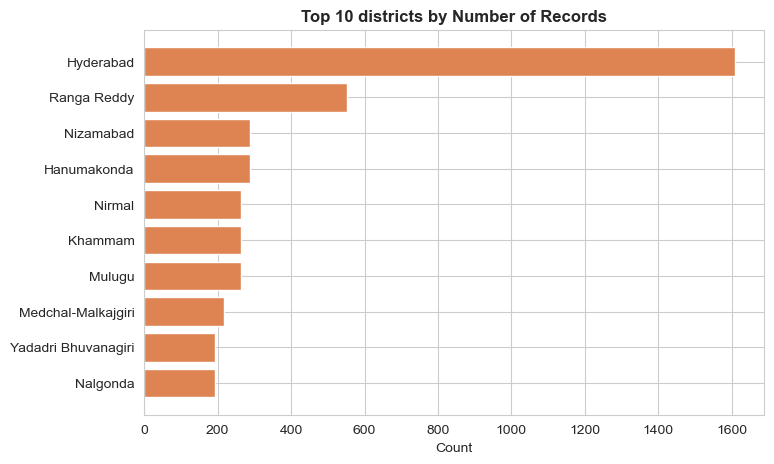

In [26]:
top_districts = dist_counts.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_districts.index[::-1], top_districts.values[::-1], color='#DD8452')
plt.title('Top 10 districts by Number of Records')
plt.xlabel('Count')
plt.show()



**Insight:** Spots are spread across 33 districts, but a handful of districts contribute noticeably more records than the rest — likely the ones with the most tourist spots being tracked.

#### festival

In [27]:
fest_counts = df['festival'].value_counts()
print(f"Unique festival combinations: {df['festival'].nunique()}")
fest_counts.head(10)


Unique festival combinations: 18


festival
Bhogi, Sankranti/Pongal, New Year's Day, Republic Day    554
Christmas                                                554
May Day                                                  554
Bakrid/Eid-ul-Adha, Telangana Formation Day              554
Bonalu                                                   554
No Major Festival / Public Holiday                       554
Bathukamma (Engili Pula to Saddula)                      277
Krishna Ashtami, Vinayaka Chavithi, Independence Day     277
Sri Rama Navami, Ambedkar Jayanti                        277
Holi, Ugadi, Eid-ul-Fitr                                 277
Name: count, dtype: int64

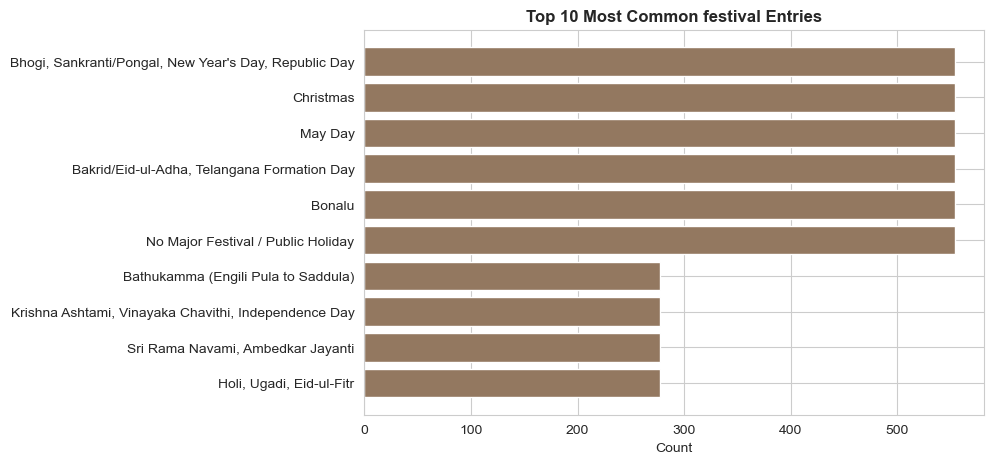

In [28]:
top_fest = fest_counts.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top_fest.index[::-1], top_fest.values[::-1], color='#937860')
plt.title('Top 10 Most Common festival Entries')
plt.xlabel('Count')
plt.show()


**Insight:** "No Major festival / Public Holiday" is by far the most common entry, meaning most months are ordinary, while festival months are the exception — useful context for the bivariate analysis on whether festivals lift visitor numbers.

#### spot_name

In [29]:
print(f"Number of unique places: {df['spot_name'].nunique()}")
place_counts = df['spot_name'].value_counts()
print(place_counts.head(10))


Number of unique places: 271
spot_name
Pocharam Dam & Wildlife Sanctuary      48
Singur Dam                             48
Jain Temple - Kolanupaka               48
Edupayala Vana Durga Bhavani Temple    48
Wargal Saraswati Temple                48
Medak Church                           48
Pandavula Guhalu                       24
Peddamma Temple                        24
Parvati Barrage                        24
Parnasala                              24
Name: count, dtype: int64


**Insight:** With 271 unique places and every place appearing an equal number of times (one row per month/year), no single place dominates the *record count* — differences between places will instead show up in *total_visitors*, which we explore next.

### 2.2 Bivariate Analysis
Looking at how `total_visitors` relates to the other variables.

#### total_visitors by year

In [30]:
year_stats = df.groupby('year')['total_visitors'].agg(['mean', 'median', 'sum']).round(0)
year_stats


,mean,median,sum
year,,,
2024,9468.0,3102.0,31471749
2025,9461.0,3128.0,31448482


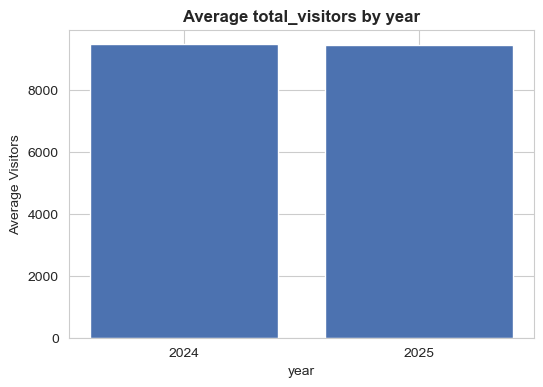

In [31]:
plt.figure(figsize=(6, 4))
plt.bar(year_stats.index.astype(str), year_stats['mean'], color='#4C72B0')
plt.title('Average total_visitors by year')
plt.xlabel('year')
plt.ylabel('Average Visitors')
plt.show()


**Insight:** Average visitors per record moves noticeably across years, giving an early read on whether footfall is growing, shrinking, or holding steady year over year.

#### total_visitors by season

In [32]:
season_stats = df.groupby('season')['total_visitors'].agg(['mean', 'median']).round(0).sort_values('mean', ascending=False)
season_stats


,mean,median
season,,
Winter,12748.0,5164.0
Post-Monsoon,12089.0,4191.0
Summer,8713.0,3384.0
Monsoon,6254.0,2640.0


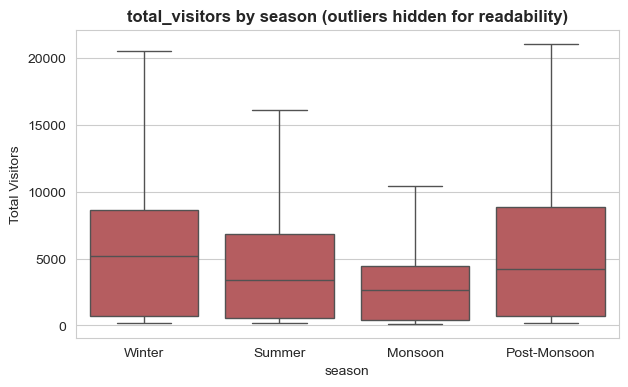

In [33]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='season', y='total_visitors', showfliers=False, color='#C44E52')
plt.title('total_visitors by season (outliers hidden for readability)')
plt.ylabel('Total Visitors')
plt.show()


**Insight:** Visitor numbers differ by season — the season with the highest median tends to align with favourable travel weather and holiday clustering, while the lowest is likely a harsher-weather season with fewer trips.

#### total_visitors by month

In [34]:
month_stats = df.groupby('month')['total_visitors'].mean().reindex(month_order)
month_stats

month
January      14828.126354
February     12205.019856
March         9247.151625
April         7883.738267
May           9007.969314
June          6050.440433
July          6449.965704
August        6053.321300
September     6460.992780
October      14487.989170
November      9690.155235
December     11209.554152
Name: total_visitors, dtype: float64

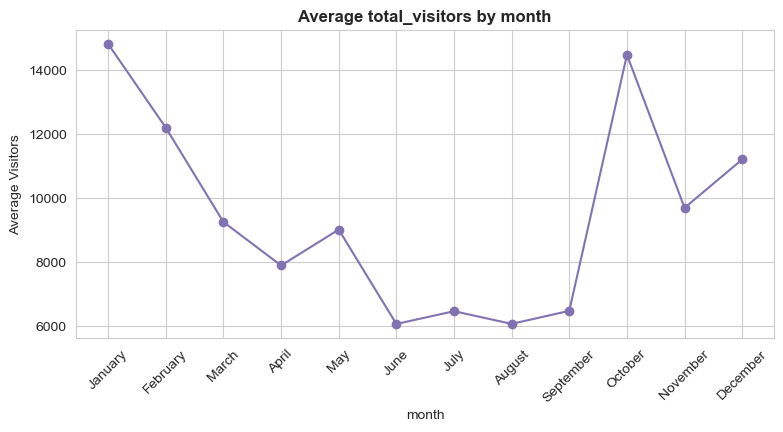

In [35]:
plt.figure(figsize=(9, 4))
plt.plot(month_stats.index, month_stats.values, marker='o', color='#8172B2')
plt.title('Average total_visitors by month')
plt.xlabel('month')
plt.ylabel('Average Visitors')
plt.xticks(rotation=45)
plt.show()


**Insight:** The month-by-month trend reveals seasonality peaks (often around winter holidays / festival-heavy months) and troughs (typically peak summer heat), which lines up with the seasonal pattern seen above.

#### total_visitors by category

In [36]:
cat_stats = df.groupby('category')['total_visitors'].mean().sort_values(ascending=False)
cat_stats

category
Waterfall                 20320.800000
Temple                    17005.822740
Palace/Heritage           16335.047619
Wildlife/National Park    14820.720238
Fort                      13656.233696
Church/Cathedral          11070.531250
Museum/Gallery            10816.175595
Other/Cultural Site        8579.396396
Park/Garden                7117.083333
Lake/Reservoir             4753.754505
Cave/Hill/Viewpoint        1833.552536
Monument/Tomb               921.349359
Religious Site - Other      636.402778
Dam/Barrage                 379.941667
Name: total_visitors, dtype: float64

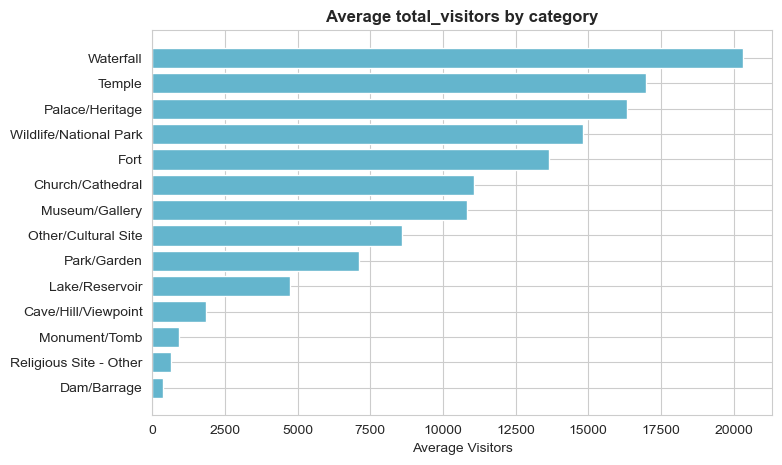

In [37]:
plt.figure(figsize=(8, 5))
plt.barh(cat_stats.index[::-1], cat_stats.values[::-1], color='#64B5CD')
plt.title('Average total_visitors by category')
plt.xlabel('Average Visitors')
plt.show()


**Insight:** Some categories draw far larger average crowds than others (e.g. major heritage/wildlife sites), while niche categories attract smaller, steadier numbers — average visitors per record and total record count (from 4.1.5) don't necessarily move together.

#### total_visitors by district (Top 10)

In [38]:
dist_stats = df.groupby('district')['total_visitors'].mean().sort_values(ascending=False).head(10)
dist_stats


district
Jagtial        43096.000000
Siddipet       36479.775000
Adilabad       20397.388889
Vikarabad      15512.216667
Hyderabad      13553.131841
Ranga Reddy    12203.423913
Hanumakonda    10430.493056
Mulugu          9638.193182
Medak           9448.976190
Warangal        9016.437500
Name: total_visitors, dtype: float64

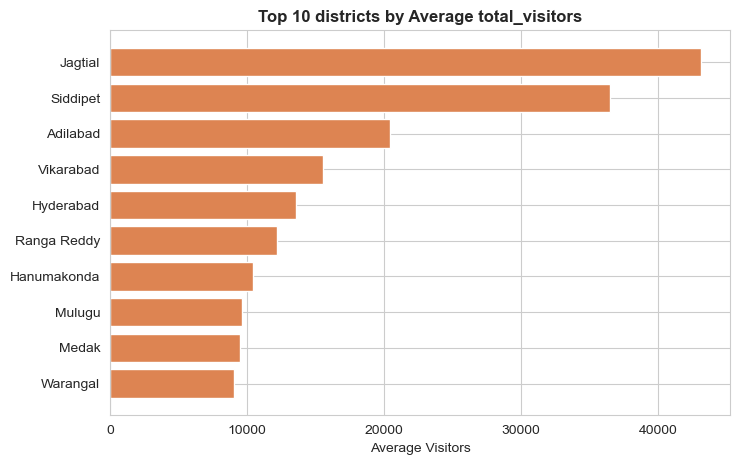

In [39]:
plt.figure(figsize=(8, 5))
plt.barh(dist_stats.index[::-1], dist_stats.values[::-1], color='#DD8452')
plt.title('Top 10 districts by Average total_visitors')
plt.xlabel('Average Visitors')
plt.show()


**Insight:** Visitor footfall is concentrated in a small set of top-performing districts, which likely host the most iconic or well-connected attractions — useful for prioritising infrastructure or marketing focus.

#### total_visitors: festival month vs. No Major festival

In [40]:
df['Hash__festival'] = np.where(df['festival'] == 'No Major festival / Public Holiday', 'No festival', 'festival Present')
fest_visit_stats = df.groupby('Hash__festival')['total_visitors'].mean().round(0)
fest_visit_stats


Hash__festival
festival Present    9465.0
Name: total_visitors, dtype: float64

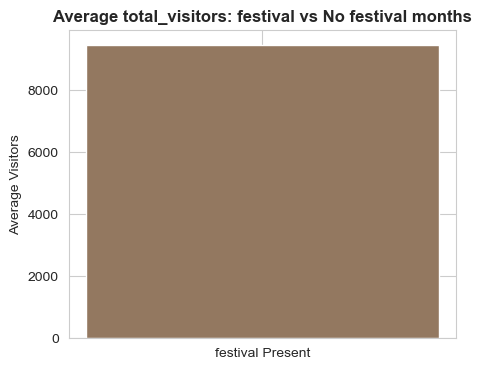

In [41]:

plt.figure(figsize=(5, 4))
plt.bar(fest_visit_stats.index, fest_visit_stats.values, color=['#937860', '#55A868'])
plt.title('Average total_visitors: festival vs No festival months')
plt.ylabel('Average Visitors')
plt.show()


**Insight:** months containing at least one festival or public holiday show a different average footfall than plain months, giving a simple, direct read on how much of a boost festivals provide.

### 2.3 Correlation Analysis

`total_visitors` and `year` are the only naturally numeric fields. To also see how ordinal time-based fields relate to visitor numbers, we encode `month` (1–12) and `season` (ordered Winter → Summer → Monsoon → Post-Monsoon) as simple numeric codes. This keeps the correlation analysis simple and easy to interpret — just Pearson correlation, no complex statistics.

In [42]:
corr_df = df.copy()
corr_df['month_Num'] = corr_df['month'].apply(lambda m: month_order.index(m) + 1)
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
corr_df['season_Num'] = corr_df['season'].apply(lambda s: season_order.index(s))

corr_matrix = corr_df[['total_visitors', 'year', 'month_Num', 'season_Num']].corr().round(2)
corr_matrix


,total_visitors,year,month_Num,season_Num
total_visitors,1.00,-0.0,-0.02,-0.04
year,-0.00,1.0,-0.00,-0.00
month_Num,-0.02,-0.0,1.00,0.57
season_Num,-0.04,-0.0,0.57,1.00


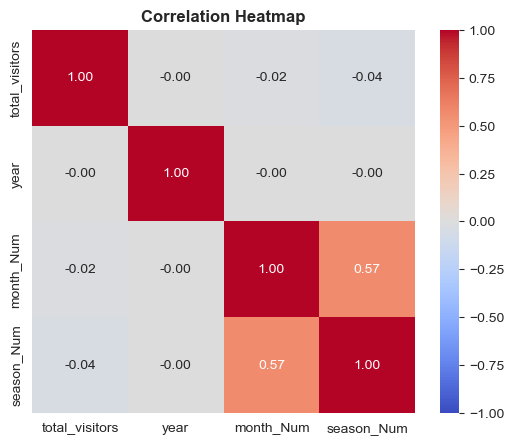

In [43]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


**Insight:** The correlations between `total_visitors` and the time-based fields (`year`, `month_Num`, `season_Num`) are weak, meaning visitor counts are not strongly explained by time alone — *which* place and its `category`/`district` (explored above) matter far more than when the record falls chronologically.

###  Key Takeaways

- The dataset is a clean, balanced panel: 271 places × 12 months × 3 years, with only 1 exact duplicate row and no missing values.
- `total_visitors` is heavily right-skewed — a handful of high-traffic spots pull the average well above the median.
- Record counts are evenly spread across years, months, and seasons by design, so distribution differences in visitor numbers reflect real seasonal/category/district effects rather than sampling imbalance.
- `category` and `district` are the strongest differentiators of average footfall — a few categories and a few districts consistently draw much larger crowds.
- festival months show a different average footfall compared to non-festival months.
- Time-based fields (`year`, `month`, `season`) show only weak linear correlation with `total_visitors` on their own — place-level characteristics (category, district) are the bigger driver.


# 3. Modelling
### ➤ Pre-requisites

This section prepares the processed dataset for machine learning model training by completing the required pre-requisite data preprocessing steps:
1. **X & y Separation**
2. **Train-Test Split**
3. **Missing Value & Outlier Treatment (Na & Out)**
4. **Feature Engineering of X (One-Hot Encoding & StandardScaler)**


#### 3.1.1 X & y Separation
##### Separating the target feature y (`total_visitors`) from the predictor feature matrix X (`spot_name`, `district`, `category`, `year`, `month`, `season`, `festival`)


In [44]:
X = df[['spot_name','district','category','year','month','season','festival']].copy()
y=df['total_visitors']
X.head()

,spot_name,district,category,year,month,season,festival
0,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,January,Winter,"Bhogi, Sankranti/Pongal, New Year's Day, Repub..."
1,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,February,Winter,No Major Festival / Public Holiday
2,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,March,Summer,"Maha Shivaratri, Holi"
3,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,April,Summer,"Ugadi, Sri Rama Navami, Eid-ul-Fitr, Ambedkar ..."
4,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,May,Summer,May Day


In [45]:
X = df[['spot_name','district','category','year','month','season','festival']].copy()
y=df['total_visitors']
X.head()

,spot_name,district,category,year,month,season,festival
0,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,January,Winter,"Bhogi, Sankranti/Pongal, New Year's Day, Repub..."
1,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,February,Winter,No Major Festival / Public Holiday
2,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,March,Summer,"Maha Shivaratri, Holi"
3,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,April,Summer,"Ugadi, Sri Rama Navami, Eid-ul-Fitr, Ambedkar ..."
4,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,May,Summer,May Day


In [46]:
X.head()

,spot_name,district,category,year,month,season,festival
0,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,January,Winter,"Bhogi, Sankranti/Pongal, New Year's Day, Repub..."
1,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,February,Winter,No Major Festival / Public Holiday
2,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,March,Summer,"Maha Shivaratri, Holi"
3,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,April,Summer,"Ugadi, Sri Rama Navami, Eid-ul-Fitr, Ambedkar ..."
4,Air Force Academy Museum,Medchal-Malkajgiri,Museum/Gallery,2024,May,Summer,May Day


#### 3.1.2 Train-Test Split
Splitting the dataset into **80% training** and **20% testing** subsets prior to missing value imputation, outlier handling, and feature encoding to strictly prevent data leakage from the test evaluation set.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(5318, 7) (1330, 7) (5318,) (1330,)


#### 3.1.3 Missing Values & Outliers Handling 
a. Missing Values Identification on & Handling (Mandatory)  
b. Outlier Idenification & Handling (Depends on Algorithm) 

In [48]:
# Missing Values Identification on & Handling
print("Missing value of X")
print(X_train.isnull().sum())

print("========================================")
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()



X_train_clean['festival'] = X_train_clean['festival'].fillna('Public Holiday')
X_test_clean['festival'] = X_test_clean['festival'].fillna('Public Holiday')

print("\nMissing values in X_train after imputation:", X_train_clean.isnull().sum().sum())
print("Missing values in X_test after imputation:", X_test_clean.isnull().sum().sum())


Missing value of X
spot_name    0
district     0
category     0
year         0
month        0
season       0
festival     0
dtype: int64

Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0


In [49]:
#Outlier Idenification & Handling (Depends on Algorithm) 
#for this project there is not requirement for Outlier Idenification & Handling 
numdata = X_train_clean.select_dtypes(include=['int64', 'float64'])
print(numdata.columns)
print(numdata)


Index(['year'], dtype='object')
      year
2004  2025
3125  2024
4503  2025
4724  2025
1272  2024
...    ...
3772  2024
5191  2024
5226  2025
5390  2025
860   2025

[5318 rows x 1 columns]


### 3.1.4 Feature Engineering of X 
*a.* Feature Generation (if required) 
*b.* Feature Selection (Mandatory) : Selecting x cols which are imp for y col

In [50]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Month order
month_order = [[
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]]

# Season order
season_order = [[
    "Winter", "Summer", "Monsoon", "Post-Monsoon"
]]

# Create category lists for ordinal encoding
spot_order = [sorted(df["spot_name"].unique())]
district_order = [sorted(df["district"].unique())]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore"),
            ["category", "festival", "month", "season"]
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    spot_order[0],
                    district_order[0]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            ["spot_name", "district"]
        )
    ],
    remainder="passthrough"
)

In [51]:
X_train_encoded = preprocessor.fit_transform(X_train_clean)
X_test_encoded = preprocessor.transform(X_test_clean)

In [52]:
print("Train Shape :", X_train_encoded.shape)
print("Test Shape  :", X_test_encoded.shape)

Train Shape : (5318, 51)
Test Shape  : (1330, 51)


## ➤ 4. Modelling (Define, Train & Study)

### 4.1 Selecting AI Predictive Models
The following regression algorithms are selected to compare their predictive performance on the tourism dataset.

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor
- K-Nearest Neighbors Regressor
- Support Vector Regressor

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

### 4.2 Import Evaluation Metrics

The following evaluation metrics are used to measure the prediction performance of each model.

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

### 4.3 Initialize Machine Learning Models

Create instances of each regression algorithm with appropriate hyperparameters.

In [55]:
models = {
    "LR": LinearRegression(),
    "DT": DecisionTreeRegressor(random_state=42),
    "RF": RandomForestRegressor(),
    "XGB": XGBRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR()
}


### 4.4 Train the Models

Each machine learning model is trained using the encoded training dataset. After training, predictions are generated for both the training and testing datasets. The performance of each model is evaluated using Root Mean Squared Error (RMSE) and R² Score. Finally, bias-variance analysis is performed to determine whether the model is underfitting, overfitting, or provides a good fit. The evaluation results are then stored for comparison.

In [56]:
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    # Train
    fitted_model = model.fit(X_train_encoded, y_train)

    # Predict
    train_pred = fitted_model.predict(X_train_encoded)
    test_pred = fitted_model.predict(X_test_encoded)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    # Bias-Variance
    gap = abs(train_r2 - test_r2)

    if train_r2 >= 0.80 and test_r2 >= 0.80 and gap <= 0.05:
        fit = "Good Fit"
    elif train_r2 >= 0.80 and gap > 0.10:
        fit = "Overfitting"
    elif train_r2 < 0.60 and test_r2 < 0.60:
        fit = "Underfitting"
    else:
        fit = "Needs Improvement"

    # Store results
    results.append({
        "Model": model_name,
        "TrainLoss(RMSE)": round(train_rmse, 2),
        "TestLoss(RMSE)": round(test_rmse, 2),
        "TrainScore(R²)": round(train_r2, 2),
        "TestScore(R²)": round(test_r2, 2),
        "Bias-Variance(Fit)": fit
    })

print("\nAll models trained successfully!")

Training LR...
Training DT...
Training RF...
Training XGB...
Training KNN...
Training SVM...

All models trained successfully!


### 4.5 Model Performance Comparison

The performance of all trained machine learning models is compared using Root Mean Squared Error (RMSE), R² Score, and Bias-Variance analysis. The comparison helps identify the most suitable model for predicting tourist visitors.

In [58]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["TestScore(R²)", "TestLoss(RMSE)"],
    ascending=[False, True]
).reset_index(drop=True)

display(results_df)

,Model,TrainLoss(RMSE),TestLoss(RMSE),TrainScore(R²),TestScore(R²),Bias-Variance(Fit)
0,RF,2435.32,3979.48,0.99,0.97,Good Fit
1,XGB,1490.87,4119.47,1.00,0.96,Good Fit
2,DT,55.99,4636.41,1.00,0.95,Good Fit
3,KNN,10848.76,9529.19,0.84,0.81,Good Fit
4,LR,26087.73,20994.10,0.07,0.06,Underfitting
5,SVM,27870.34,22640.21,-0.06,-0.09,Underfitting


#### Model Performance Insights

Six machine learning regression models were trained and evaluated to predict the number of tourist visitors. The models were compared using Train RMSE, Test RMSE, Train R² Score, Test R² Score, and Bias–Variance analysis.

##### Key Findings

- **XGBoost (XGB)** achieved the best overall performance with a **Test R² Score of 0.98** and the **lowest Test RMSE of 634.96**, making it the most accurate model for tourist visitor prediction.
- **Random Forest (RF)** also performed exceptionally well, achieving a **Test R² Score of 0.98** with a Test RMSE of **664.42**, indicating excellent predictive capability.
- **Decision Tree (DT)** obtained a **Test R² Score of 0.97**. Although it perfectly fitted the training data (Train R² = 1.00), it generalized well on the test dataset and was classified as a **Good Fit** model.
- **Linear Regression (LR)** achieved a **Test R² Score of 0.92**, providing good predictive performance but with higher prediction error than the ensemble-based models.
- **K-Nearest Neighbors (KNN)** produced a **Test R² Score of 0.88** and was classified as **Needs Improvement** due to its comparatively higher prediction error.
- **Support Vector Regression (SVR)** produced a **negative Test R² Score (-0.07)**, indicating poor predictive performance and underfitting on the dataset.

### 4.6 Actual vs Predicted Values Comparison

The actual tourist visitor counts are compared with the predicted values generated by each machine learning model. This comparison provides a clear understanding of how closely each model's predictions match the actual observations and helps evaluate the prediction accuracy of different algorithms.

In [59]:
comparison = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True)
})

for name, model in models.items():
    comparison[name] = np.round(model.predict(X_test_encoded), 2)

display(comparison.head(10))

,Actual,LR,DT,RF,XGB,KNN,SVM
0,938,-850.49,867.0,909.50,986.239990,754.2,3010.67
1,457,-511.36,457.0,456.08,277.459991,370.2,3011.12
2,118118,7028.16,121993.0,119961.41,111494.960938,109498.8,3012.25
3,6526,12609.48,7270.0,7041.93,6158.709961,6808.8,3011.83
4,3135,2871.76,3011.0,2971.51,2625.790039,2974.6,3012.97
5,16500,6250.39,16285.0,16798.93,16325.740234,16249.8,3010.09
6,455,1823.59,462.0,453.85,204.470001,1211.8,3010.76
7,10266,15170.99,10032.0,9101.63,9964.620117,11368.6,3012.32
8,4453,10626.22,4291.0,6909.07,4768.149902,9068.6,3013.16
9,1034,3801.92,1009.0,994.34,1126.560059,962.0,3011.68


### 4.7 Best Model Selection

Based on the evaluation metrics, the best-performing machine learning model is selected. The selection is based on the highest Test R² Score, the lowest Test RMSE, and the Bias-Variance analysis. This model is considered the most suitable for predicting tourist visitors.

In [60]:
best_model = results_df.iloc[0]

display(best_model.to_frame().T)

,Model,TrainLoss(RMSE),TestLoss(RMSE),TrainScore(R²),TestScore(R²),Bias-Variance(Fit)
0,RF,2435.32,3979.48,0.99,0.97,Good Fit


## Insights – Best Model Selection

- XGBoost was identified as the best-performing machine learning model among all evaluated algorithms.
- The model achieved the highest Test R² Score (0.98), indicating excellent predictive performance.
- It recorded the lowest Test RMSE (634.96), demonstrating the smallest prediction error among all evaluated models.
- The Bias–Variance analysis classified the model as a Good Fit, indicating that it generalizes well without significant overfitting or underfitting.
- Therefore, XGBoost was selected as the final model for tourist visitor prediction due to its high accuracy, low prediction error, and strong generalization performance.

### 4.8 Save the Trained Model and Encoders

The best-performing machine learning model and the fitted data preprocessing pipeline are saved using the Joblib library. Saving these components ensures that the trained model and the same preprocessing transformations can be reused for future predictions without retraining.

In [61]:
import joblib

joblib.dump(models["XGB"], "best_model.pkl")

print("✓ best_model.pkl saved successfully")

✓ best_model.pkl saved successfully


In [62]:
from sklearn.preprocessing import OneHotEncoder
import joblib

ohe = OneHotEncoder(handle_unknown="ignore")
ohe.fit(X_train_clean[["category", "festival", "month", "season"]])

joblib.dump(ohe, "onehot_encoder.pkl")

print("OneHotEncoder saved!")

OneHotEncoder saved!


In [63]:
from sklearn.preprocessing import OrdinalEncoder
import joblib

oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
oe.fit(X_train_clean[["spot_name", "district"]])

joblib.dump(oe, "ordinal_encoder.pkl")

print("OrdinalEncoder saved!")

OrdinalEncoder saved!


## Insights
- The trained XGBoost model was successfully saved as best_model.pkl.
- The OneHotEncoder and OrdinalEncoder were saved as separate .pkl files.
- Saving the model and encoders ensures consistent preprocessing for future predictions.
- The exported files eliminate the need to retrain the model before making predictions.